C:\Users\USER\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning:

Blowfish has been deprecated



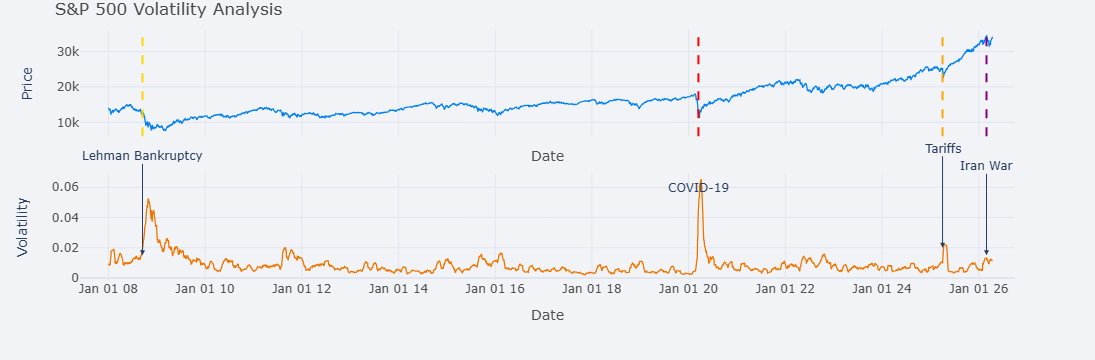

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import cufflinks as cf
import plotly.offline as plyo 

plyo.init_notebook_mode(connected=True)
cf.go_offline()

# 1. Download data (S&P 500)
df = yf.download("^GSPTSE", 
    start="2007-01-01", 
    # end="2020-12-31",
    progress=False
)

# 2. Clean
df = df[["Close"]].rename(columns={"Close": "adj_close"})

# 3. Returns
df["log_rtn"] = np.log(df["adj_close"] / df["adj_close"].shift(1))

# 4. Rolling volatility (NOW it exists)
df["rolling_std_21"] = df["log_rtn"].rolling(21).std()
df["rolling_std_252"] = df["log_rtn"].rolling(252).std()

df = df.dropna()

# 5. Plot
fig = df[["adj_close", "rolling_std_21"]].iplot(
    theme='polar',
    title='S&P 500 Volatility Analysis',
    xTitle='Date',
    subplots=True,
    # subplot_titles=("Price", "Volatility"),
    shape=(2, 1),
    shared_xaxes=True,
    legend=False,
    asFigure=True
)


# Annotations on volatility subplot (y2)
fig.add_annotation(x='2020-03-15', y=0.06, yref='y2', text="COVID-19", showarrow=False, arrowhead=2, ax=0, ay=-20)
fig.add_annotation(x='2025-04-02', y=0.02, yref='y2', text="Tariffs", showarrow=True, arrowhead=2, ax=0, ay=-100)
fig.add_annotation(x='2026-02-28', y=0.015, yref='y2', text="Iran War", showarrow=True, arrowhead=2, ax=0, ay=-90)
fig.add_annotation(x='2008-09-15', y=0.015, yref='y2', text="Lehman Bankruptcy", showarrow=True, arrowhead=2, ax=0, ay=-100)


fig.add_vline(
    x="2008-09-15",
    line_width=2,
    # line_width=2,
    line_dash="dash",
    line_color="gold"
)

fig.add_vline(
    x="2020-03-15",
    line_width=2,
    line_dash="dash",
    line_color="red"
)

fig.add_vline(
    x="2025-04-02",
    line_width=2,
    line_dash="dash",
    line_color="orange"
)

fig.add_vline(
    x="2026-02-28",
    line_width=2,
    line_dash="dash",
    line_color="purple"
)
fig.update_layout(
    margin=dict(t=30)  # more top space
)
fig.update_layout(
    yaxis=dict(title='Price'),
    yaxis2=dict(title='Volatility')
)

fig.update_xaxes(tickformat="%b %d %y")

fig.show()